In [1]:
from pathlib import Path
from functools import partial
import json
import os
import platform
import time
import random
import warnings

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import KernelPCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

import xgboost as xgb

os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass

RANDOM_STATE = 42
TASKS = ['grade', 'tp53']          
K_VALUES_BY_TASK = {'grade': [50], 'tp53': [50]}  # paper defaults; extend for sweeps
STAGE3_EPOCHS = 200
STAGE3_PATIENCE = 20
STAGE3_BATCH_SIZE = 32
STAGE3_LR = 1e-3
OUTPUT_DIR = Path('efficiency_results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_KPCA_COMPONENTS = max(k for ks in K_VALUES_BY_TASK.values() for k in ks)

DATA_DIR = Path('/home/gandalf/Documents/Data/Deep Mut/')
MUT_INFO_PATH = DATA_DIR / 'mut_info.tsv'
RNASEQ_PATH = DATA_DIR / 'rnaseq_data.tsv'
META_PATH = DATA_DIR / 'meta_data.tsv'

print('Tasks:', TASKS)
print('K values by task:', K_VALUES_BY_TASK)
print('Output directory:', OUTPUT_DIR.resolve())

Tasks: ['grade', 'tp53']
K values by task: {'grade': [50], 'tp53': [50]}
Output directory: /home/gandalf/Documents/Github/Mer Lab/OmicSieve/efficiency_results


In [2]:
def collect_environment_info():
    info = {
        'timestamp_utc': pd.Timestamp.utcnow().isoformat(),
        'platform': platform.platform(),
        'processor': platform.processor() or platform.machine(),
        'python_version': platform.python_version(),
        'cpu_count_logical': os.cpu_count(),
        'torch_version': torch.__version__,
        'xgboost_version': xgb.__version__,
        'cuda_available': torch.cuda.is_available(),
        'cuda_device_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        'random_state': RANDOM_STATE,
        'xgboost_n_jobs': 1,
        'stage3_epochs': STAGE3_EPOCHS,
        'k_values_by_task': K_VALUES_BY_TASK,
    }
    try:
        import psutil
        info['ram_total_gb'] = round(psutil.virtual_memory().total / (1024 ** 3), 2)
    except Exception:
        info['ram_total_gb'] = None
    return info

env_info = collect_environment_info()
with open(OUTPUT_DIR / 'environment_info.json', 'w') as f:
    json.dump(env_info, f, indent=2)
pd.Series(env_info)

timestamp_utc                     2026-07-06T16:02:05.853016+00:00
platform             Linux-6.17.0-35-generic-x86_64-with-glibc2.39
processor                                                   x86_64
python_version                                              3.12.3
cpu_count_logical                                               22
torch_version                                          2.5.1+cu124
xgboost_version                                              3.0.0
cuda_available                                               False
cuda_device_name                                              None
random_state                                                    42
xgboost_n_jobs                                                   1
stage3_epochs                                                  200
k_values_by_task                     {'grade': [50], 'tp53': [50]}
ram_total_gb                                                 62.25
dtype: object

## Data loading and preprocessing

In [3]:
def _clean_meta(df: pd.DataFrame) -> pd.DataFrame:
    meta = df.copy()
    meta.columns = (
        meta.columns.astype(str)
        .str.strip()
        .str.strip('"')
        .str.lower()
        .str.replace(' ', '_', regex=False)
    )
    if 'sample' in meta.columns:
        meta['patient_id'] = meta['sample'].astype(str).str.strip().str.replace('"', '')
    meta = meta.dropna(subset=['patient_id']).drop_duplicates('patient_id')
    if 'histological_grade' in meta.columns:
        meta['histological_grade'] = (
            meta['histological_grade'].astype(str).str.strip().str.upper().replace({'': pd.NA})
        )
    return meta


def _clean_rnaseq(df: pd.DataFrame) -> pd.DataFrame:
    gnames = df.columns.astype(str).str.strip().str.replace('"', '')
    sample_ids = df.iloc[:, 0].astype(str).str.strip().str.replace('"', '')
    expr_data = df.iloc[:, 1:].copy()
    expr_data.columns = gnames[:len(expr_data.columns)]
    expr_data = expr_data.apply(pd.to_numeric, errors='coerce')
    rna_clean = pd.concat([sample_ids.reset_index(drop=True), expr_data.reset_index(drop=True)], axis=1)
    rna_clean.columns = ['patient_id'] + list(expr_data.columns)
    rna_clean = rna_clean[rna_clean['patient_id'].str.len() > 0].dropna(subset=['patient_id'])
    rna_clean = rna_clean.set_index('patient_id')
    rna_final = rna_clean.groupby(level=0).mean().T
    rna_final['gene_id'] = rna_final.index
    rna_final = rna_final[['gene_id'] + [c for c in rna_final.columns if c != 'gene_id']]
    return rna_final.reset_index(drop=True)


def grade_to_risk_label(grade):
    low_risk_grades = {'G1', 'LOW GRADE'}
    high_risk_grades = {'G3', 'G4', 'HIGH GRADE'}
    if pd.isna(grade):
        return pd.NA
    g = str(grade).strip().upper()
    if g in low_risk_grades:
        return 0
    if g in high_risk_grades:
        return 1
    return pd.NA


def build_task_labeled_data(task_name, meta_clean, rnaseq_clean, mut_info_path):
    task_name = str(task_name).strip().lower()
    rnaseq_patient_ids = set(rnaseq_clean.columns) - {'gene_id'}
    matched_patient_ids = sorted(set(meta_clean['patient_id']) & rnaseq_patient_ids)
    meta_task = meta_clean[meta_clean['patient_id'].isin(matched_patient_ids)].copy().reset_index(drop=True)
    rnaseq_task = rnaseq_clean[['gene_id'] + matched_patient_ids].copy().reset_index(drop=True)

    if task_name == 'grade':
        meta_task['label'] = meta_task['histological_grade'].apply(grade_to_risk_label)
    elif task_name == 'tp53':
        mut_df = pd.read_csv(mut_info_path, sep='\t', dtype=str)
        mut_df.columns = (
            mut_df.columns.astype(str).str.strip().str.strip('"').str.lower().str.replace(' ', '_', regex=False)
        )
        index_ids = pd.Index(mut_df.index).astype(str)
        if index_ids.str.match(r'^TCGA-[A-Z0-9]+-[A-Z0-9]+-\d+').mean() > 0.5:
            mut_df = mut_df.copy()
            mut_df['patient_id'] = index_ids.str.strip().str.replace('"', '')
            id_col = 'patient_id'
        else:
            id_col = next((c for c in ['patient_id', 'sample', 'x_patient', 'rnaseqid', 'sample_id', 'mutid'] if c in mut_df.columns), mut_df.columns[0])
            mut_df[id_col] = mut_df[id_col].astype(str).str.strip().str.replace('"', '')
        mut_df = mut_df.dropna(subset=[id_col]).drop_duplicates(id_col)
        tp53_col = next((c for c in mut_df.columns if c != id_col and 'tp53' in c.lower()), None)
        if tp53_col is None:
            raise ValueError('Could not locate a TP53 column in mut_info.tsv')
        binary_mut_info = mut_df[[id_col, tp53_col]].copy()
        binary_mut_info['label'] = binary_mut_info[tp53_col].apply(lambda x: 0 if str(x).strip().lower() == 'wild' else 1)
        meta_task['label'] = meta_task['patient_id'].map(binary_mut_info.set_index(id_col)['label'])
    else:
        raise ValueError(f'Unknown task: {task_name}')

    labeled_meta_df = meta_task[meta_task['label'].notna()].copy().reset_index(drop=True)
    labeled_meta_df['label'] = labeled_meta_df['label'].astype(int)
    ordered_patient_ids = sorted(set(labeled_meta_df['patient_id']) & rnaseq_patient_ids)
    labeled_meta_df = labeled_meta_df.set_index('patient_id').loc[ordered_patient_ids].reset_index()
    labeled_rnaseq_df = rnaseq_task[['gene_id'] + ordered_patient_ids].reset_index(drop=True)
    return labeled_meta_df, labeled_rnaseq_df


def prepare_data(X, y, test_size=0.15, val_size=0.15, random_state=RANDOM_STATE):
    splitter1 = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_val_idx, test_idx = next(splitter1.split(X, y))
    X_train_val, y_train_val = X[train_val_idx], y[train_val_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    val_size_adjusted = val_size / (1.0 - test_size)
    splitter2 = StratifiedShuffleSplit(n_splits=1, test_size=val_size_adjusted, random_state=random_state)
    train_idx, val_idx = next(splitter2.split(X_train_val, y_train_val))
    X_train, y_train = X_train_val[train_idx], y_train_val[train_idx]
    X_val, y_val = X_train_val[val_idx], y_train_val[val_idx]

    scaler = StandardScaler()
    return {
        'X_train': scaler.fit_transform(X_train),
        'y_train': y_train.astype(int),
        'X_val': scaler.transform(X_val),
        'y_val': y_val.astype(int),
        'X_test': scaler.transform(X_test),
        'y_test': y_test.astype(int),
        'n_features': X.shape[1],
        'n_trainval': len(X_train) + len(X_val),
        'n_test': len(X_test),
    }


meta_df = pd.read_csv(META_PATH, sep='\t')
header_df = pd.read_csv(RNASEQ_PATH, sep='\t', header=None, nrows=1, dtype=str)
gene_names = header_df.iloc[0, :].tolist()
rnaseq_df = pd.read_csv(RNASEQ_PATH, sep='\t', header=None, skiprows=1, dtype=str, engine='python', on_bad_lines='warn')
if rnaseq_df.shape[1] > len(gene_names):
    rnaseq_df = rnaseq_df.iloc[:, :len(gene_names)]
elif rnaseq_df.shape[1] < len(gene_names):
    for _ in range(len(gene_names) - rnaseq_df.shape[1]):
        rnaseq_df[len(rnaseq_df.columns)] = None
rnaseq_df.columns = gene_names
rnaseq_df = rnaseq_df.rename(columns={gene_names[0]: 'sample_id'})

clean_meta_df = _clean_meta(meta_df)
clean_rnaseq_df = _clean_rnaseq(rnaseq_df)

task_datasets = {}
for task in TASKS:
    labeled_meta_df, labeled_rnaseq_df = build_task_labeled_data(task, clean_meta_df, clean_rnaseq_df, MUT_INFO_PATH)
    X_raw = labeled_rnaseq_df.drop('gene_id', axis=1).T.values
    y_binary = labeled_meta_df['label'].values.astype(int)
    data = prepare_data(X_raw, y_binary)
    task_datasets[task] = data
    print(f"[{task}] train/val/test shapes: {data['X_train'].shape}, {data['X_val'].shape}, {data['X_test'].shape}")

[grade] train/val/test shapes: (1745, 19310), (374, 19310), (375, 19310)
[tp53] train/val/test shapes: (6738, 19310), (1444, 19310), (1444, 19310)


## Model building blocks

In [4]:
def class_weights(y):
    n_pos = int((y == 1).sum())
    n_neg = int((y == 0).sum())
    scale_pos_weight = float(n_neg) / float(max(n_pos, 1))
    n_samples = len(y)
    w_neg = n_samples / (2.0 * max(n_neg, 1))
    w_pos = n_samples / (2.0 * max(n_pos, 1))
    sample_weight = np.where(y == 1, w_pos, w_neg)
    return scale_pos_weight, sample_weight


def build_xgb_classifier(scale_pos_weight, random_state=RANDOM_STATE):
    return xgb.XGBClassifier(
        n_estimators=350,
        max_depth=8,
        learning_rate=0.07,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1,
        reg_lambda=5.0,
        gamma=0.0,
        scale_pos_weight=scale_pos_weight,
        max_delta_step=3,
        random_state=random_state,
        n_jobs=1,
        eval_metric='logloss',
        verbose=0,
    )


def time_xgb_holdout_train_predict(X_trainval, y_trainval, X_test):
    scale_pos_weight, sample_weight = class_weights(y_trainval)
    model = build_xgb_classifier(scale_pos_weight)
    t0 = time.time()
    model.fit(X_trainval, y_trainval, sample_weight=sample_weight)
    train_time_s = time.time() - t0
    t0 = time.time()
    _ = model.predict(X_test)
    infer_per_sample_ms = (time.time() - t0) / max(len(X_test), 1) * 1000
    return train_time_s, infer_per_sample_ms


class FeatureAttentionBlock(nn.Module):
    def __init__(self, dim, dropout=0.2, se_ratio=0.25):
        super().__init__()
        hidden = max(32, dim // 2)
        se_hidden = max(16, int(dim * se_ratio))
        self.norm = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, dim), nn.Dropout(dropout),
        )
        self.gate = nn.Sequential(nn.Linear(dim, dim), nn.Sigmoid())
        self.channel_attn = nn.Sequential(
            nn.Linear(dim, se_hidden), nn.ReLU(), nn.Linear(se_hidden, dim), nn.Sigmoid(),
        )

    def forward(self, x):
        h = self.norm(x)
        x = x + (self.ff(h) * self.gate(h))
        scale = self.channel_attn(x)
        return x * scale + x


class AttentionFeatureSelectorMLP(nn.Module):
    def __init__(self, n_input_genes, n_output_components, hidden_dims=None, dropout=0.4):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [1024, 512, 256, 128]
        self.stem = nn.Sequential(
            nn.Linear(n_input_genes, hidden_dims[0]), nn.BatchNorm1d(hidden_dims[0]),
            nn.GELU(), nn.Dropout(dropout),
        )
        blocks, transitions = [], []
        for i, dim in enumerate(hidden_dims):
            blocks.append(FeatureAttentionBlock(dim, dropout=dropout))
            if i < len(hidden_dims) - 1:
                transitions.append(nn.Sequential(
                    nn.Linear(dim, hidden_dims[i + 1]), nn.BatchNorm1d(hidden_dims[i + 1]),
                    nn.GELU(), nn.Dropout(dropout),
                ))
        self.blocks = nn.ModuleList(blocks)
        self.transitions = nn.ModuleList(transitions)
        self.component_head = nn.Linear(hidden_dims[-1], n_output_components)

    def forward(self, x):
        h = self.stem(x)
        for i, block in enumerate(self.blocks):
            h = block(h)
            if i < len(self.transitions):
                h = self.transitions[i](h)
        return self.component_head(h)


def mine_triplets_from_distances(dist_matrix, n_triplets=512, random_state=RANDOM_STATE):
    rng = np.random.RandomState(random_state)
    n = dist_matrix.shape[0]
    anchors, positives, negatives = [], [], []
    for _ in range(n_triplets):
        anchor = rng.randint(0, n)
        dists = dist_matrix[anchor].copy()
        dists[anchor] = np.inf
        positive = int(np.argmin(dists))
        median_dist = np.median(dists[dists < np.inf])
        far_candidates = np.where(dists > median_dist)[0]
        if len(far_candidates) == 0:
            far_candidates = np.argsort(dists)[-10:]
        negative = int(rng.choice(far_candidates))
        anchors.append(anchor)
        positives.append(positive)
        negatives.append(negative)
    return np.array(anchors), np.array(positives), np.array(negatives)

## Timed benchmark functions

In [5]:
def benchmark_full_feature_xgboost(data, task):
    X_trainval = np.vstack([data['X_train'], data['X_val']])
    y_trainval = np.concatenate([data['y_train'], data['y_val']])
    train_time_s, infer_per_sample_ms = time_xgb_holdout_train_predict(X_trainval, y_trainval, data['X_test'])
    return {
        'task': task,
        'method': 'Full-feature XGBoost',
        'k': data['n_features'],
        'n_trainval': data['n_trainval'],
        'n_test': data['n_test'],
        'xgb_train_time_s': train_time_s,
        'xgb_infer_per_sample_ms': infer_per_sample_ms,
        'selection_time_s': 0.0,
        'selector_train_time_s': 0.0,
        'total_pipeline_time_s': train_time_s,
        'speedup_vs_full_xgb': 1.0,
    }


def benchmark_feature_selection_xgboost(data, task, method_name, score_func, k):
    X_train, y_train = data['X_train'], data['y_train']
    X_val, y_val = data['X_val'], data['y_val']
    X_test = data['X_test']

    # prepare_data() already StandardScaler-normalized X_*; do not scale again
    t0 = time.time()
    k_eff = min(k, X_train.shape[1])
    selector = SelectKBest(score_func=score_func, k=k_eff)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_val_selected = selector.transform(X_val)
    X_test_selected = selector.transform(X_test)
    selection_time_s = time.time() - t0

    X_trainval = np.vstack([X_train_selected, X_val_selected])
    y_trainval = np.concatenate([y_train, y_val])
    train_time_s, infer_per_sample_ms = time_xgb_holdout_train_predict(X_trainval, y_trainval, X_test_selected)
    total_time_s = selection_time_s + train_time_s
    return {
        'task': task,
        'method': method_name,
        'k': k_eff,
        'n_trainval': data['n_trainval'],
        'n_test': data['n_test'],
        'selection_time_s': selection_time_s,
        'selector_train_time_s': 0.0,
        'xgb_train_time_s': train_time_s,
        'xgb_infer_per_sample_ms': infer_per_sample_ms,
        'total_pipeline_time_s': total_time_s,
    }


def benchmark_omicsieve(data, task, k, n_components=N_KPCA_COMPONENTS):
    timings = {'task': task, 'method': 'OmicSieve', 'k': k}

    # Stage 1: KPCA
    t0 = time.time()
    component_op = Pipeline([
        ('scaler', StandardScaler()),
        ('kpca', KernelPCA(n_components=n_components, kernel='rbf', fit_inverse_transform=False)),
    ])
    X_train_components = component_op.fit_transform(data['X_train'])
    X_val_components = component_op.transform(data['X_val'])
    timings['stage1_kpca_time_s'] = time.time() - t0

    # Stage 2: silhouette ranking
    t0 = time.time()
    component_scores = np.zeros(X_train_components.shape[1])
    for i in range(X_train_components.shape[1]):
        xi = X_train_components[:, [i]]
        try:
            labels = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10).fit_predict(xi)
            component_scores[i] = abs(float(silhouette_score(xi, labels))) if len(np.unique(labels)) > 1 else 0.0
        except Exception:
            component_scores[i] = 0.0
    top_k_indices = np.argsort(component_scores)[::-1][:min(k, X_train_components.shape[1])].tolist()
    timings['stage2_ranking_time_s'] = time.time() - t0

    # Stage 3: MLP selector
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)
    target_scaler = StandardScaler()
    component_targets_train = target_scaler.fit_transform(X_train_components[:, top_k_indices])
    component_targets_val = target_scaler.transform(X_val_components[:, top_k_indices])
    X_train_tensor = torch.FloatTensor(data['X_train'])
    y_train_comp_tensor = torch.FloatTensor(component_targets_train)
    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_comp_tensor), batch_size=STAGE3_BATCH_SIZE, shuffle=True)
    X_val_tensor = torch.FloatTensor(data['X_val'])
    y_val_comp_tensor = torch.FloatTensor(component_targets_val)
    dist_matrix = pairwise_distances(X_train_components, metric='euclidean')
    anc_idx, pos_idx, neg_idx = mine_triplets_from_distances(dist_matrix, n_triplets=1024, random_state=RANDOM_STATE)
    model = AttentionFeatureSelectorMLP(data['X_train'].shape[1], len(top_k_indices), dropout=0.2)
    optimizer = optim.Adam(model.parameters(), lr=STAGE3_LR, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)
    component_criterion = nn.MSELoss()
    triplet_criterion = nn.TripletMarginLoss(margin=1.0, p=2)
    best_val_loss, patience_counter, best_state = float('inf'), 0, None

    t0 = time.time()
    for epoch in range(STAGE3_EPOCHS):
        model.train()
        for batch_X, batch_comp in train_loader:
            optimizer.zero_grad()
            loss = component_criterion(model(batch_X), batch_comp)
            loss.backward()
            optimizer.step()
        if len(anc_idx) > 0:
            model.train()
            optimizer.zero_grad()
            triplet_loss = triplet_criterion(
                model(torch.FloatTensor(data['X_train'][anc_idx])),
                model(torch.FloatTensor(data['X_train'][pos_idx])),
                model(torch.FloatTensor(data['X_train'][neg_idx])),
            ) * 0.3
            triplet_loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            val_loss = float(component_criterion(model(X_val_tensor), y_val_comp_tensor).item())
        if val_loss < best_val_loss:
            best_val_loss, patience_counter, best_state = val_loss, 0, {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
        scheduler.step(val_loss)
        if patience_counter >= STAGE3_PATIENCE:
            break
    timings['stage3_mlp_train_time_s'] = time.time() - t0
    if best_state is not None:
        model.load_state_dict(best_state)

    # MLP inference on all splits
    t0 = time.time()
    model.eval()
    with torch.no_grad():
        X_train_topk = model(torch.FloatTensor(data['X_train'])).numpy()
        X_val_topk = model(torch.FloatTensor(data['X_val'])).numpy()
        X_test_topk = model(torch.FloatTensor(data['X_test'])).numpy()
    n_total = data['n_trainval'] + data['n_test']
    timings['mlp_infer_per_sample_ms'] = (time.time() - t0) / max(n_total, 1) * 1000

    # Stage 4: reduced-feature XGBoost
    X_trainval_topk = np.vstack([X_train_topk, X_val_topk])
    y_trainval = np.concatenate([data['y_train'], data['y_val']])
    xgb_train_time_s, xgb_infer_per_sample_ms = time_xgb_holdout_train_predict(X_trainval_topk, y_trainval, X_test_topk)
    timings['stage4_xgb_train_time_s'] = xgb_train_time_s
    timings['stage4_xgb_infer_per_sample_ms'] = xgb_infer_per_sample_ms

    timings.update({
        'n_trainval': data['n_trainval'],
        'n_test': data['n_test'],
        'selection_time_s': timings['stage1_kpca_time_s'] + timings['stage2_ranking_time_s'],
        'selector_train_time_s': timings['stage3_mlp_train_time_s'],
        'xgb_train_time_s': timings['stage4_xgb_train_time_s'],
        'xgb_infer_per_sample_ms': timings['stage4_xgb_infer_per_sample_ms'],
        'total_pipeline_time_s': (
            timings['stage1_kpca_time_s'] + timings['stage2_ranking_time_s'] +
            timings['stage3_mlp_train_time_s'] + timings['stage4_xgb_train_time_s']
        ),
    })
    return timings

## Run benchmarks

In [6]:
FEATURE_SELECTION_METHODS = {
    'ANOVA + XGBoost': f_classif,
    'Mutual Information + XGBoost': partial(mutual_info_classif, random_state=RANDOM_STATE),
}

all_rows = []
stage_rows = []

for task in TASKS:
    data = task_datasets[task]
    print('\n' + '=' * 90)
    print(f'TASK: {task.upper()}')
    print('=' * 90)

    print('\n[1/3] Full-feature XGBoost baseline')
    full_row = benchmark_full_feature_xgboost(data, task)
    all_rows.append(full_row)
    print(f"  XGBoost train time: {full_row['xgb_train_time_s']:.2f}s")

    k_values = K_VALUES_BY_TASK.get(task, [50])

    for k in k_values:
        print(f'\n[2/3] OmicSieve pipeline (k={k})')
        omic_row = benchmark_omicsieve(data, task, k)
        omic_row['speedup_vs_full_xgb'] = full_row['xgb_train_time_s'] / max(omic_row['xgb_train_time_s'], 1e-9)
        all_rows.append({
            'task': task,
            'method': 'OmicSieve',
            'k': k,
            'n_trainval': data['n_trainval'],
            'n_test': data['n_test'],
            'selection_time_s': omic_row['selection_time_s'],
            'selector_train_time_s': omic_row['selector_train_time_s'],
            'xgb_train_time_s': omic_row['xgb_train_time_s'],
            'xgb_infer_per_sample_ms': omic_row['xgb_infer_per_sample_ms'],
            'total_pipeline_time_s': omic_row['total_pipeline_time_s'],
            'speedup_vs_full_xgb': omic_row['speedup_vs_full_xgb'],
        })
        stage_rows.append(omic_row)
        print(f"  Stage 1 (KPCA): {omic_row['stage1_kpca_time_s']:.2f}s")
        print(f"  Stage 2 (ranking): {omic_row['stage2_ranking_time_s']:.2f}s")
        print(f"  Stage 3 (MLP): {omic_row['stage3_mlp_train_time_s']:.2f}s")
        print(f"  Stage 4 (XGBoost): {omic_row['stage4_xgb_train_time_s']:.2f}s")
        print(f"  XGBoost speedup vs full baseline: {omic_row['speedup_vs_full_xgb']:.1f}x")

        print(f'\n[3/3] Compact feature-selection baselines (k={k})')
        for method_name, score_func in FEATURE_SELECTION_METHODS.items():
            fs_row = benchmark_feature_selection_xgboost(data, task, method_name, score_func, k)
            fs_row['speedup_vs_full_xgb'] = full_row['xgb_train_time_s'] / max(fs_row['xgb_train_time_s'], 1e-9)
            all_rows.append(fs_row)
            print(f"  {method_name}: selection={fs_row['selection_time_s']:.2f}s, XGBoost train={fs_row['xgb_train_time_s']:.2f}s")

summary_df = pd.DataFrame(all_rows)
stage_df = pd.DataFrame(stage_rows)
summary_df


TASK: GRADE

[1/3] Full-feature XGBoost baseline
  XGBoost train time: 473.74s

[2/3] OmicSieve pipeline (k=50)
  Stage 1 (KPCA): 2.76s
  Stage 2 (ranking): 4.58s
  Stage 3 (MLP): 2226.53s
  Stage 4 (XGBoost): 1.32s
  XGBoost speedup vs full baseline: 357.9x

[3/3] Compact feature-selection baselines (k=50)
  ANOVA + XGBoost: selection=0.74s, XGBoost train=1.25s
  Mutual Information + XGBoost: selection=113.05s, XGBoost train=1.17s

TASK: TP53

[1/3] Full-feature XGBoost baseline
  XGBoost train time: 2429.26s

[2/3] OmicSieve pipeline (k=50)
  Stage 1 (KPCA): 28.97s
  Stage 2 (ranking): 39.98s
  Stage 3 (MLP): 37385.68s
  Stage 4 (XGBoost): 7.58s
  XGBoost speedup vs full baseline: 320.7x

[3/3] Compact feature-selection baselines (k=50)
  ANOVA + XGBoost: selection=2.98s, XGBoost train=5.24s
  Mutual Information + XGBoost: selection=630.06s, XGBoost train=5.69s


,task,method,k,n_trainval,n_test,xgb_train_time_s,xgb_infer_per_sample_ms,selection_time_s,selector_train_time_s,total_pipeline_time_s,speedup_vs_full_xgb
0,grade,Full-feature XGBoost,19310,2119,375,473.741762,0.086342,0.000000,0.000000,473.741762,1.000000
1,grade,OmicSieve,50,2119,375,1.323668,0.018408,7.348617,2226.527379,2235.199665,357.900614
2,grade,ANOVA + XGBoost,50,2119,375,1.250026,0.017941,0.742908,0.000000,1.992935,378.985386
3,grade,Mutual Information + XGBoost,50,2119,375,1.169742,0.017993,113.050523,0.000000,114.220265,404.996676
4,tp53,Full-feature XGBoost,19310,8182,1444,2429.256615,0.090269,0.000000,0.000000,2429.256615,1.000000
5,tp53,OmicSieve,50,8182,1444,7.575829,0.012326,68.956188,37385.683990,37462.216007,320.658839
6,tp53,ANOVA + XGBoost,50,8182,1444,5.240666,0.012062,2.979963,0.000000,8.220629,463.539641
7,tp53,Mutual Information + XGBoost,50,8182,1444,5.690408,0.012444,630.061469,0.000000,635.751877,426.903786


## Summary tables and reviewer-ready text

In [7]:
display_cols = [
    'task', 'method', 'k', 'n_trainval', 'n_test',
    'selection_time_s', 'selector_train_time_s', 'xgb_train_time_s',
    'xgb_infer_per_sample_ms', 'total_pipeline_time_s', 'speedup_vs_full_xgb',
]
summary_display = summary_df[display_cols].copy()
summary_display = summary_display.sort_values(['task', 'method', 'k']).reset_index(drop=True)

summary_csv = OUTPUT_DIR / 'computational_efficiency_summary.csv'
summary_display.to_csv(summary_csv, index=False)
stage_csv = OUTPUT_DIR / 'omicsieve_stage_timings.csv'
stage_df.to_csv(stage_csv, index=False)

print('Saved:', summary_csv)
print('Saved:', stage_csv)
summary_display

Saved: efficiency_results/computational_efficiency_summary.csv
Saved: efficiency_results/omicsieve_stage_timings.csv


,task,method,k,n_trainval,n_test,selection_time_s,selector_train_time_s,xgb_train_time_s,xgb_infer_per_sample_ms,total_pipeline_time_s,speedup_vs_full_xgb
0,grade,ANOVA + XGBoost,50,2119,375,0.742908,0.000000,1.250026,0.017941,1.992935,378.985386
1,grade,Full-feature XGBoost,19310,2119,375,0.000000,0.000000,473.741762,0.086342,473.741762,1.000000
2,grade,Mutual Information + XGBoost,50,2119,375,113.050523,0.000000,1.169742,0.017993,114.220265,404.996676
3,grade,OmicSieve,50,2119,375,7.348617,2226.527379,1.323668,0.018408,2235.199665,357.900614
4,tp53,ANOVA + XGBoost,50,8182,1444,2.979963,0.000000,5.240666,0.012062,8.220629,463.539641
5,tp53,Full-feature XGBoost,19310,8182,1444,0.000000,0.000000,2429.256615,0.090269,2429.256615,1.000000
6,tp53,Mutual Information + XGBoost,50,8182,1444,630.061469,0.000000,5.690408,0.012444,635.751877,426.903786
7,tp53,OmicSieve,50,8182,1444,68.956188,37385.683990,7.575829,0.012326,37462.216007,320.658839


In [8]:
def format_seconds(seconds):
    if seconds >= 120:
        return f"{seconds / 60:.1f} min ({seconds:.1f} s)"
    return f"{seconds:.2f} s"

reviewer_lines = []
for task in TASKS:
    task_df = summary_display[summary_display['task'] == task]
    full = task_df[task_df['method'] == 'Full-feature XGBoost'].iloc[0]
    reviewer_lines.append(f"### {task.upper()}")
    reviewer_lines.append(
        f"- Full-feature XGBoost ({int(full['k'])} genes, n_train+val={int(full['n_trainval'])}): "
        f"train {format_seconds(full['xgb_train_time_s'])}."
    )
    k_values = K_VALUES_BY_TASK.get(task, [50])
    for k in k_values:
        omic = task_df[(task_df['method'] == 'OmicSieve') & (task_df['k'] == k)].iloc[0]
        stage = stage_df[(stage_df['task'] == task) & (stage_df['k'] == k)].iloc[0]
        reviewer_lines.append(
            f"- OmicSieve (k={k}): Stage 4 XGBoost train {format_seconds(omic['xgb_train_time_s'])} "
            f"({omic['speedup_vs_full_xgb']:.0f}x faster than full-feature XGBoost training); "
            f"full pipeline {format_seconds(omic['total_pipeline_time_s'])} "
            f"(KPCA {stage['stage1_kpca_time_s']:.1f}s + ranking {stage['stage2_ranking_time_s']:.1f}s + "
            f"MLP {stage['stage3_mlp_train_time_s']:.1f}s + XGBoost {stage['stage4_xgb_train_time_s']:.1f}s)."
        )
    reviewer_lines.append('')

reviewer_text = '\n'.join(reviewer_lines)
reviewer_path = OUTPUT_DIR / 'reviewer_timing_summary.md'
with open(reviewer_path, 'w') as f:
    f.write('# Computational efficiency summary\n\n')
    f.write(reviewer_text)
print(reviewer_text)
print('\nSaved:', reviewer_path)

### GRADE
- Full-feature XGBoost (19310 genes, n_train+val=2119): train 7.9 min (473.7 s).
- OmicSieve (k=50): Stage 4 XGBoost train 1.32 s (358x faster than full-feature XGBoost training); full pipeline 37.3 min (2235.2 s) (KPCA 2.8s + ranking 4.6s + MLP 2226.5s + XGBoost 1.3s).

### TP53
- Full-feature XGBoost (19310 genes, n_train+val=8182): train 40.5 min (2429.3 s).
- OmicSieve (k=50): Stage 4 XGBoost train 7.58 s (321x faster than full-feature XGBoost training); full pipeline 624.4 min (37462.2 s) (KPCA 29.0s + ranking 40.0s + MLP 37385.7s + XGBoost 7.6s).


Saved: efficiency_results/reviewer_timing_summary.md


## Figures

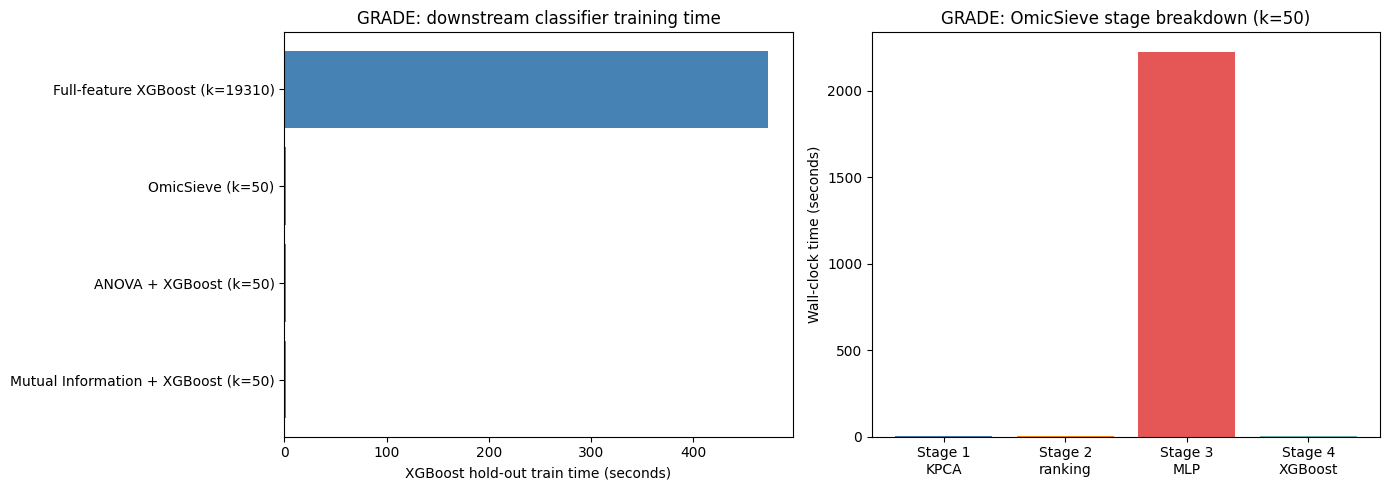

Saved figure: efficiency_results/grade_computational_efficiency.png


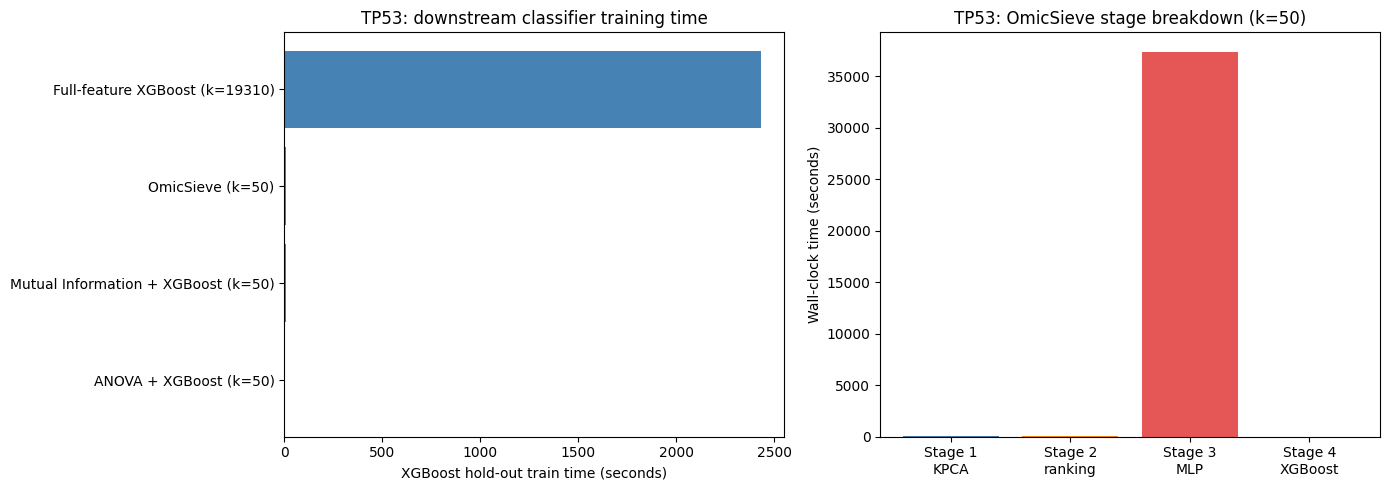

Saved figure: efficiency_results/tp53_computational_efficiency.png


In [9]:
for task in TASKS:
    task_df = summary_display[summary_display['task'] == task].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel A: XGBoost training time only
    plot_df = task_df.sort_values('xgb_train_time_s', ascending=False)
    axes[0].barh(plot_df['method'] + ' (k=' + plot_df['k'].astype(str) + ')', plot_df['xgb_train_time_s'], color='steelblue')
    axes[0].set_xlabel('XGBoost hold-out train time (seconds)')
    axes[0].set_title(f'{task.upper()}: downstream classifier training time')
    axes[0].invert_yaxis()

    # Panel B: OmicSieve stage breakdown
    if not stage_df.empty and task in stage_df['task'].values:
        k_values = K_VALUES_BY_TASK.get(task, [50])
        for k in k_values:
            s = stage_df[(stage_df['task'] == task) & (stage_df['k'] == k)].iloc[0]
            stages = ['Stage 1\nKPCA', 'Stage 2\nranking', 'Stage 3\nMLP', 'Stage 4\nXGBoost']
            values = [s['stage1_kpca_time_s'], s['stage2_ranking_time_s'], s['stage3_mlp_train_time_s'], s['stage4_xgb_train_time_s']]
            axes[1].bar(stages, values, color=['#4C78A8', '#F58518', '#E45756', '#72B7B2'])
            axes[1].set_ylabel('Wall-clock time (seconds)')
            axes[1].set_title(f'{task.upper()}: OmicSieve stage breakdown (k={k})')
    else:
        axes[1].axis('off')

    fig.tight_layout()
    fig_path = OUTPUT_DIR / f'{task}_computational_efficiency.png'
    fig.savefig(fig_path, dpi=160, bbox_inches='tight')
    plt.show()
    print('Saved figure:', fig_path)